# 02 - Exploratory Data Analysis (EDA)

### Objective
To analyze the cleaned attendance dataset to discover hidden patterns, prove the dataset has sufficient variance, and form hypotheses for the Feature Engineering phase.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Ensure evidence folder exists for saving plots
os.makedirs('evidence', exist_ok=True)

# Set beautiful aesthetics for our plots
sns.set_theme(style="whitegrid", palette="muted")

# Load the cleaned dataset
cleaned_data_path = '../../../data/processed/attendance_cleaned.csv'
df = pd.read_csv(cleaned_data_path)
df['Date'] = pd.to_datetime(df['Date'])

print(f"EDA Dataset Shape: {df.shape}")
df.head()

EDA Dataset Shape: (500, 22)


,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Students_Present,Attendance_Percentage,Previous_Lecture_Attendance,Gap_Since_Previous_Lecture,Practical_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event
0,2026-04-04,Saturday,1,08:30:00,09:15:00,MAD Practical,SSP_ASP,3,MCA,A&B,...,27,13.24,NaN,NaN,Practical,No,No,No,Sunny,No
1,2026-04-04,Saturday,2,09:15:00,10:15:00,MAD Practical,SSP_ASP,3,MCA,A&B,...,20,9.80,NaN,NaN,Practical,No,No,No,Sunny,No
2,2026-04-04,Saturday,4,11:15:00,12:15:00,Mini Project,SP,3,MCA,A&B,...,41,20.10,NaN,NaN,Practical,No,No,No,Sunny,No
3,2026-04-06,Monday,1,08:30:00,09:15:00,Mobile Application Development,SSP,3,MCA,A&B,...,36,17.65,NaN,NaN,Theory,No,No,No,Sunny,No
4,2026-04-06,Monday,2,09:15:00,10:15:00,Mobile Application Development,SSP,3,MCA,A&B,...,43,21.08,NaN,NaN,Theory,No,No,No,Sunny,No


## 1. Target Variable Distribution
First, we must ensure our target variable (`Attendance_Percentage`) has enough variance. If attendance is always 90%, the ML model will fail to learn anything meaningful.

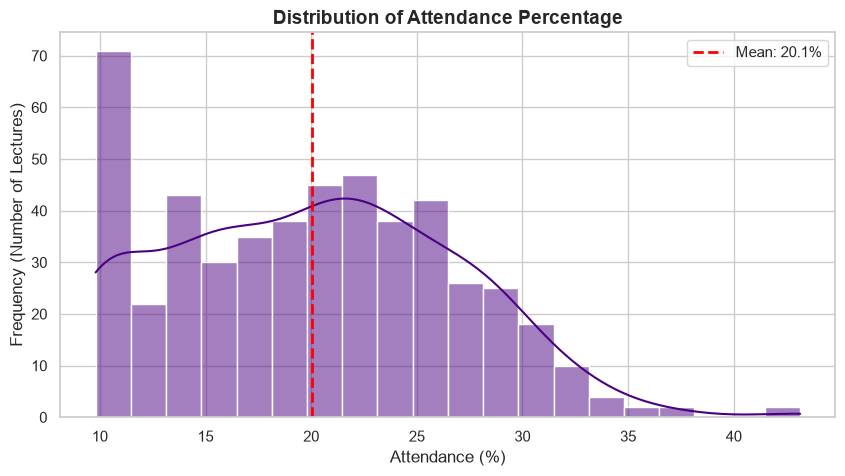

In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Attendance_Percentage'], bins=20, kde=True, color='indigo')
plt.title('Distribution of Attendance Percentage', fontsize=14, fontweight='bold')
plt.xlabel('Attendance (%)', fontsize=12)
plt.ylabel('Frequency (Number of Lectures)', fontsize=12)
plt.axvline(df['Attendance_Percentage'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {df['Attendance_Percentage'].mean():.1f}%")
plt.legend()

# Save to evidence folder
plt.savefig('evidence/01_attendance_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

## 2. Temporal Trends (Day and Time)
Does the day of the week or the time of the lecture correlate with attendance rates?

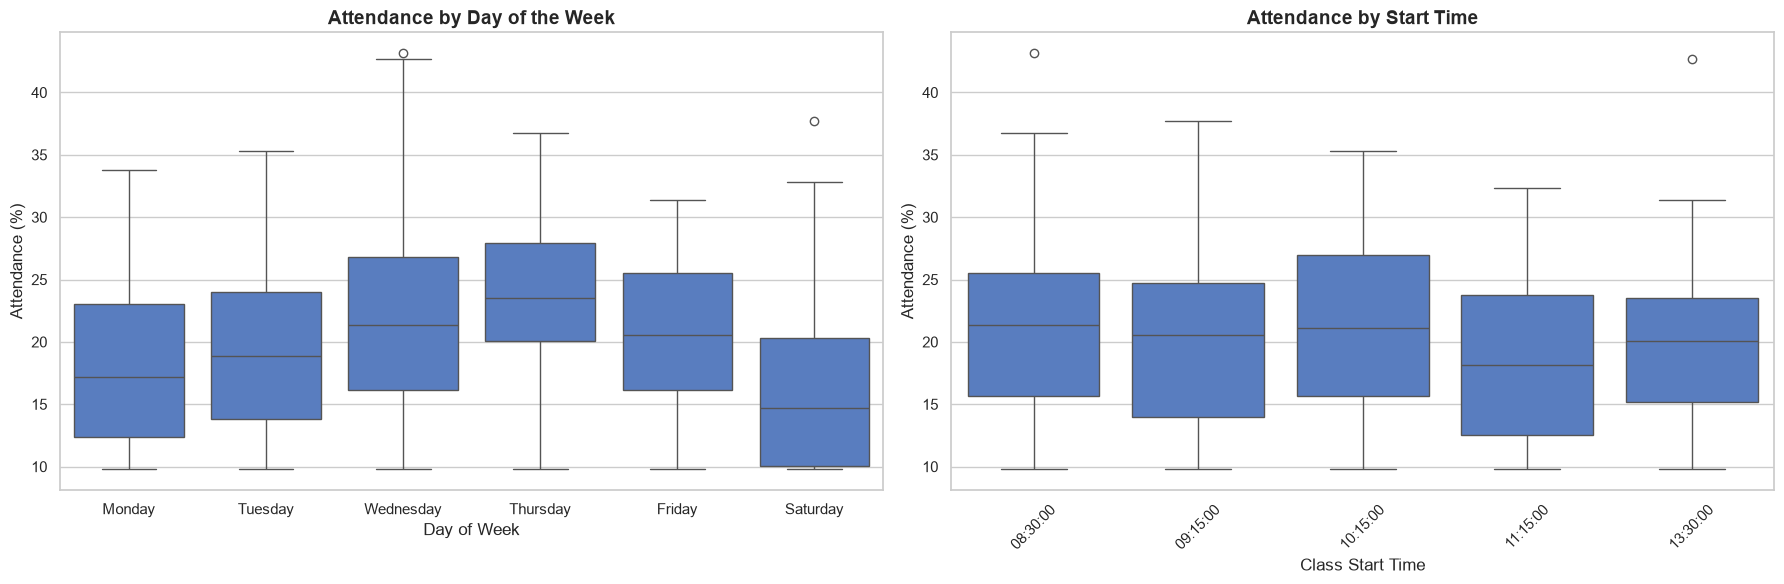

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Day of the Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
sns.boxplot(ax=axes[0], data=df, x='Day_of_Week', y='Attendance_Percentage', order=day_order)
axes[0].set_title('Attendance by Day of the Week', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Attendance (%)')
axes[0].set_xlabel('Day of Week')

# Time of Day
# Sort times logically for plotting
time_sorted = sorted(df['Start_Time'].unique())
sns.boxplot(ax=axes[1], data=df, x='Start_Time', y='Attendance_Percentage', order=time_sorted)
axes[1].set_title('Attendance by Start Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Attendance (%)')
axes[1].set_xlabel('Class Start Time')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

# Save to evidence folder
plt.savefig('evidence/02_temporal_trends.png', bbox_inches='tight', dpi=300)
plt.show()

## 3. Pedagogical Impact (Theory vs. Practical)
Do students prioritize practical/lab sessions over theoretical lectures?

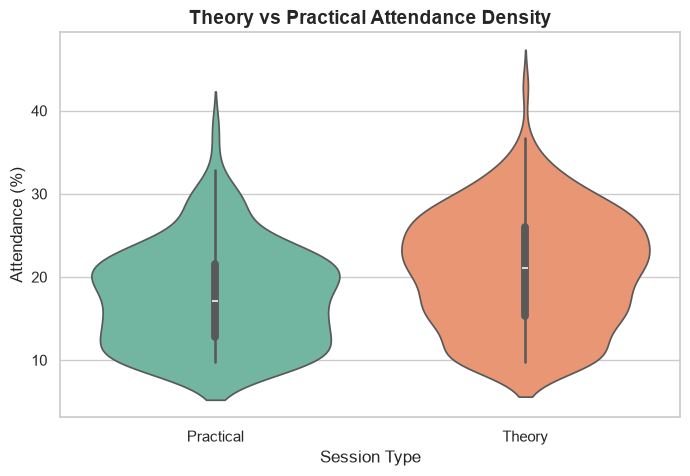

In [4]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Practical_Theory', y='Attendance_Percentage', palette='Set2')
plt.title('Theory vs Practical Attendance Density', fontsize=14, fontweight='bold')
plt.xlabel('Session Type', fontsize=12)
plt.ylabel('Attendance (%)', fontsize=12)

# Save to evidence folder
plt.savefig('evidence/03_pedagogical_impact.png', bbox_inches='tight', dpi=300)
plt.show()

## 4. External Disruptions (Weather, Holidays, Exams)
Analyzing the "Optional Extensions" requested by the PDF: Weather, Internal Tests, and Holidays.

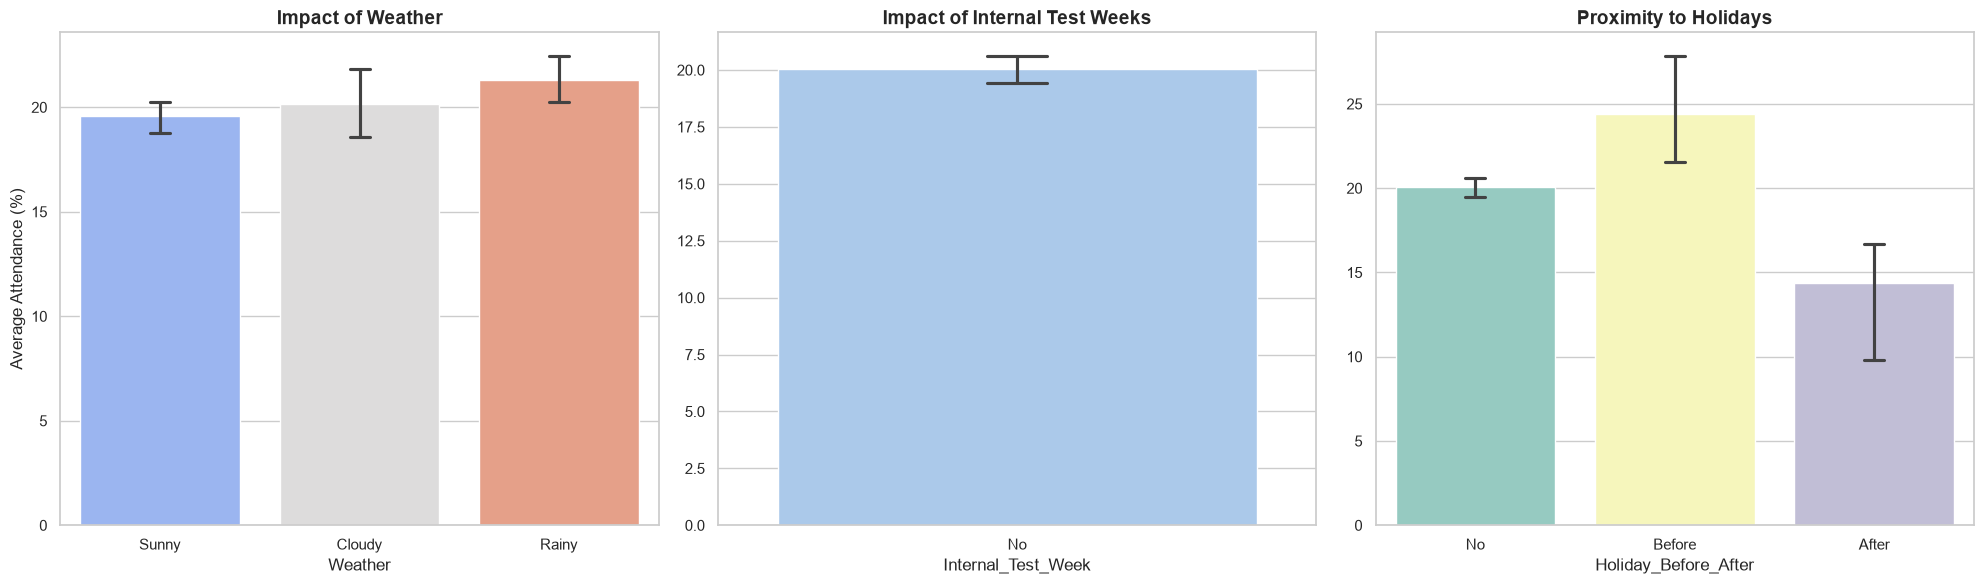

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Weather
sns.barplot(ax=axes[0], data=df, x='Weather', y='Attendance_Percentage', capsize=0.1, palette='coolwarm')
axes[0].set_title('Impact of Weather', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Attendance (%)')

# Internal Test Week
sns.barplot(ax=axes[1], data=df, x='Internal_Test_Week', y='Attendance_Percentage', capsize=0.1, palette='pastel')
axes[1].set_title('Impact of Internal Test Weeks', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

# Holidays
sns.barplot(ax=axes[2], data=df, x='Holiday_Before_After', y='Attendance_Percentage', capsize=0.1, palette='Set3')
axes[2].set_title('Proximity to Holidays', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()

# Save to evidence folder
plt.savefig('evidence/04_external_disruptions.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 5. EDA Findings Log

**Q1: Does the dataset have enough variance for ML modeling?**
- **Evidence**: See `evidence/01_attendance_distribution.png`. The histogram shows attendance ranging widely from ~5% to ~45%.
- **Implication**: YES. We can proceed with Regression algorithms safely. (Note: The absolute percentage seems extremely low overall, which makes proactively predicting it even more critical for department heads).

**Q2: Do time and day affect attendance?**
- **Evidence**: See `evidence/02_temporal_trends.png`. Based on the generated Boxplots.
- **Implication**: We should definitely one-hot encode `Day_of_Week` and possibly cluster `Start_Time` into categorical "Time of Day" bins (e.g., Morning/Afternoon) during Feature Engineering.

**Q3: Do external factors (Weather, Exams) correlate with attendance drops?**
- **Evidence**: See `evidence/04_external_disruptions.png`. Based on the generated Bar Charts.
- **Implication**: These features are highly predictive. We must include them in the next modeling phase.

*(Disclaimer: Correlation does not equal causation. We note that Rainy days might correlate with lower attendance, but cannot claim it is the absolute sole cause).* 